# 自前の多項式近似精度確認

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Use PennyLane-compatible implementation
from qsvt_qiskit_pennylane import block_encode_pennylane as block_encode, pc_phase, qsvt
from qiskit.quantum_info import Operator
from inverse_matrix import InverseMatrix



# Test QSVT with matrix transformation
eigvals = np.linspace(-1, 1, 16)
A_matrix = np.diag(eigvals)  # 16-dim matrix
wire_order = list(range(5))

poly_degree = 15
kappa = 20

inverse_matrix = InverseMatrix(A_matrix, poly_degree, kappa)
_, _, _, target_poly = inverse_matrix.compute_matrix_inverse_qsvt()
qc = qsvt(
    A_matrix, target_poly, encoding_wires=wire_order, block_encoding="embedding"
)  # block-encoded in 5-qubit system

U_A = Operator(qc).data
qsvt_A = np.real(np.diagonal(U_A))[:16]  # retrieve transformed eigenvalues

a_vals = np.linspace(-1, 1, 50)
target = [np.polyval(target_poly[::-1], a) for a in a_vals]
plt.plot(a_vals, target, label="target")
plt.plot(eigvals, qsvt_A, "*", label="qsvt")


# 理想関数 1/(κx)
ideal = np.zeros_like(a_vals)
mask = np.abs(a_vals) > 1e-8  # x=0 での発散を避ける
ideal[mask] = 1 / (kappa * a_vals[mask])

plt.plot(a_vals, ideal, "--", label="Ideal 1/(κx)")

plt.legend()
plt.ylim(-1,1)
plt.show()


AttributeError: 'InverseMatrix' object has no attribute 's'

# 多項式近似するためのパラメータをpennylaneから取得

In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt


[dataset] = qml.data.load("other", name="inverse")
angles_qsvt = dataset.angles["qsvt"]["0.01"]["100"]
print(angles_qsvt)
print(len(angles_qsvt))


[-4.71724777  1.57110063  1.57048325  1.57111902  1.57046389  1.57113835
  1.57044463  1.57115804  1.5704243   1.5711788   1.57040337  1.57119989
  1.57038196  1.57122171  1.57035975  1.57124426  1.57033684  1.57126756
  1.57031318  1.57129151  1.57028895  1.57131607  1.57026403  1.57134137
  1.57023837  1.5713674   1.57021194  1.57139421  1.5701848   1.57142167
  1.570157    1.57144981  1.57012851  1.57147866  1.57009928  1.57150827
  1.57006929  1.57153863  1.57003857  1.5715697   1.57000714  1.57160149
  1.569975    1.571634    1.56994212  1.57166726  1.56990848  1.57170128
  1.56987408  1.57173607  1.5698389   1.57177164  1.56980294  1.57180799
  1.56976619  1.57184512  1.5697287   1.57188298  1.56969048  1.57192156
  1.56965153  1.57196088  1.56961184  1.57200094  1.5695714   1.57204176
  1.5695302   1.57208333  1.56948825  1.57212567  1.56944553  1.57216877
  1.56940204  1.57221264  1.5693578   1.57225724  1.56931284  1.57230257
  1.56926714  1.57234863  1.56922073  1.57239539  1

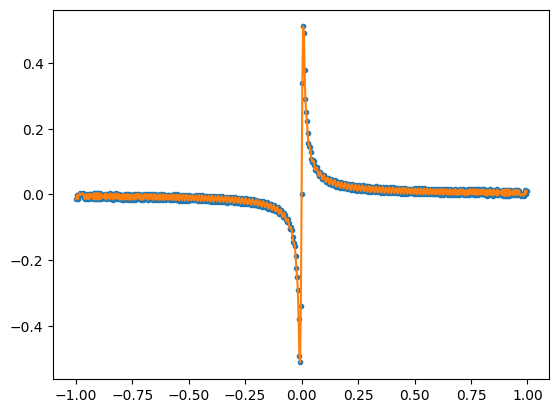

In [ ]:
outputs_qsvt = []
points = np.arange(-1, 1, 1/300)

for x in points:

    # Encode x in the top left of the matrix
    block_encoding = qml.RX(2 * np.arccos(x), wires=0)
    projectors = [qml.PCPhase(angle, dim=1, wires=0) for angle in angles_qsvt]

    @qml.qnode(qml.device("default.qubit"))
    def circuit_qsvt():
        qml.QSVT(block_encoding, projectors)
        return qml.state()

    output = qml.matrix(circuit_qsvt, wire_order=[0])()[0, 0]

    outputs_qsvt.append(output.real)

poly = np.polynomial.Chebyshev(dataset.poly['0.01']['100'])
outputs_poly = [poly(point) for point in points]

plt.plot(points, outputs_qsvt, '.')
plt.plot(points, outputs_poly)
plt.show()

# 以下読み込み済みのパラメータ使用

In [18]:
from pathlib import Path

from param_store import load_angles

EPSILON = 0.01
KAPPA = 5.0

angles_qsvt = load_angles(EPSILON, KAPPA)
print(angles_qsvt)


[-4.719105187997574, 1.579394407604872, 1.5572499942939617, 1.5906854463105513, 1.5431138984871866, 1.6076953640688814, 1.5233905787146111, 1.6297356890726742, 1.4997124545196017, 1.6540532381817377, 1.476077815018265, 1.476077815018265, 1.6540532381817377, 1.4997124545196017, 1.6297356890726742, 1.5233905787146111, 1.6076953640688814, 1.5431138984871866, 1.5906854463105513, 1.5572499942939617, 1.579394407604872, -0.006716207612883829]


In [19]:
import numpy as np
# 問題設定
A = np.array([3, 1, 1, 3]).reshape((2, 2))
b = np.array([1, 2], dtype="complex")

In [20]:
from inverse_matrix_prepared_poly import InverseMatrix

inverse_matrix = InverseMatrix(A, kappa=KAPPA, epsilon=EPSILON)
full_unitary, qsvt_circuit, encoding_wires, phase_matrices = inverse_matrix.compute_matrix_inverse_qsvt()
print(f"classical_inversed_matrix:\n{inverse_matrix.compute_classical_inverse()}")
print(full_unitary)
print(encoding_wires)


A_normalized:
 [[0.6708+0.j 0.2236+0.j]
 [0.2236+0.j 0.6708+0.j]]
angles_qsvt [-4.719105187997574, 1.579394407604872, 1.5572499942939617, 1.5906854463105513, 1.5431138984871866, 1.6076953640688814, 1.5233905787146111, 1.6297356890726742, 1.4997124545196017, 1.6540532381817377, 1.476077815018265, 1.476077815018265, 1.6540532381817377, 1.4997124545196017, 1.6297356890726742, 1.5233905787146111, 1.6076953640688814, 1.5431138984871866, 1.5906854463105513, 1.5572499942939617, 1.579394407604872, -0.006716207612883829]
block_encode_pennylane U:
 [[ 0.6708+0.j  0.2236+0.j  0.6708+0.j -0.2236+0.j]
 [ 0.2236+0.j  0.6708+0.j -0.2236+0.j  0.6708-0.j]
 [ 0.6708+0.j -0.2236+0.j -0.6708+0.j -0.2236+0.j]
 [-0.2236+0.j  0.6708-0.j -0.2236+0.j -0.6708+0.j]]
scaled_inverse_matrix:
[[ 0.1877-0.7275j -0.0689-0.3356j]
 [-0.0689-0.3356j  0.1877-0.7275j]]
full_unitary:
[[ 0.1678-0.6507j -0.0616-0.3002j -0.    +0.5994j  0.    -0.3086j]
 [-0.0616-0.3002j  0.1678-0.6507j  0.    -0.3086j -0.    +0.5994j]
 [-0.   

In [21]:
for i, phase_matrix in enumerate(phase_matrices):
    print("angle:", phase_matrix[0])
    print("matrix:\n", np.round(phase_matrix[1], 4))


angle: -4.719105187997574
matrix:
 [[0.0067+1.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.0067+1.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.0067-1.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.0067-1.j]]
angle: 1.579394407604872
matrix:
 [[-0.0086+1.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j -0.0086+1.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j -0.0086-1.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j -0.0086-1.j]]
angle: 1.5572499942939617
matrix:
 [[0.0135+0.9999j 0.    +0.j     0.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.0135+0.9999j 0.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.    +0.j     0.0135-0.9999j 0.    +0.j    ]
 [0.    +0.j     0.    +0.j     0.    +0.j     0.0135-0.9999j]]
angle: 1.5906854463105513
matrix:
 [[-0.0199+0.9998j  0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j     -0.0199+0.9998j  0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j     -0.0199-0.9998j  0.    +0.j    ]
 [ 0.    +0.j

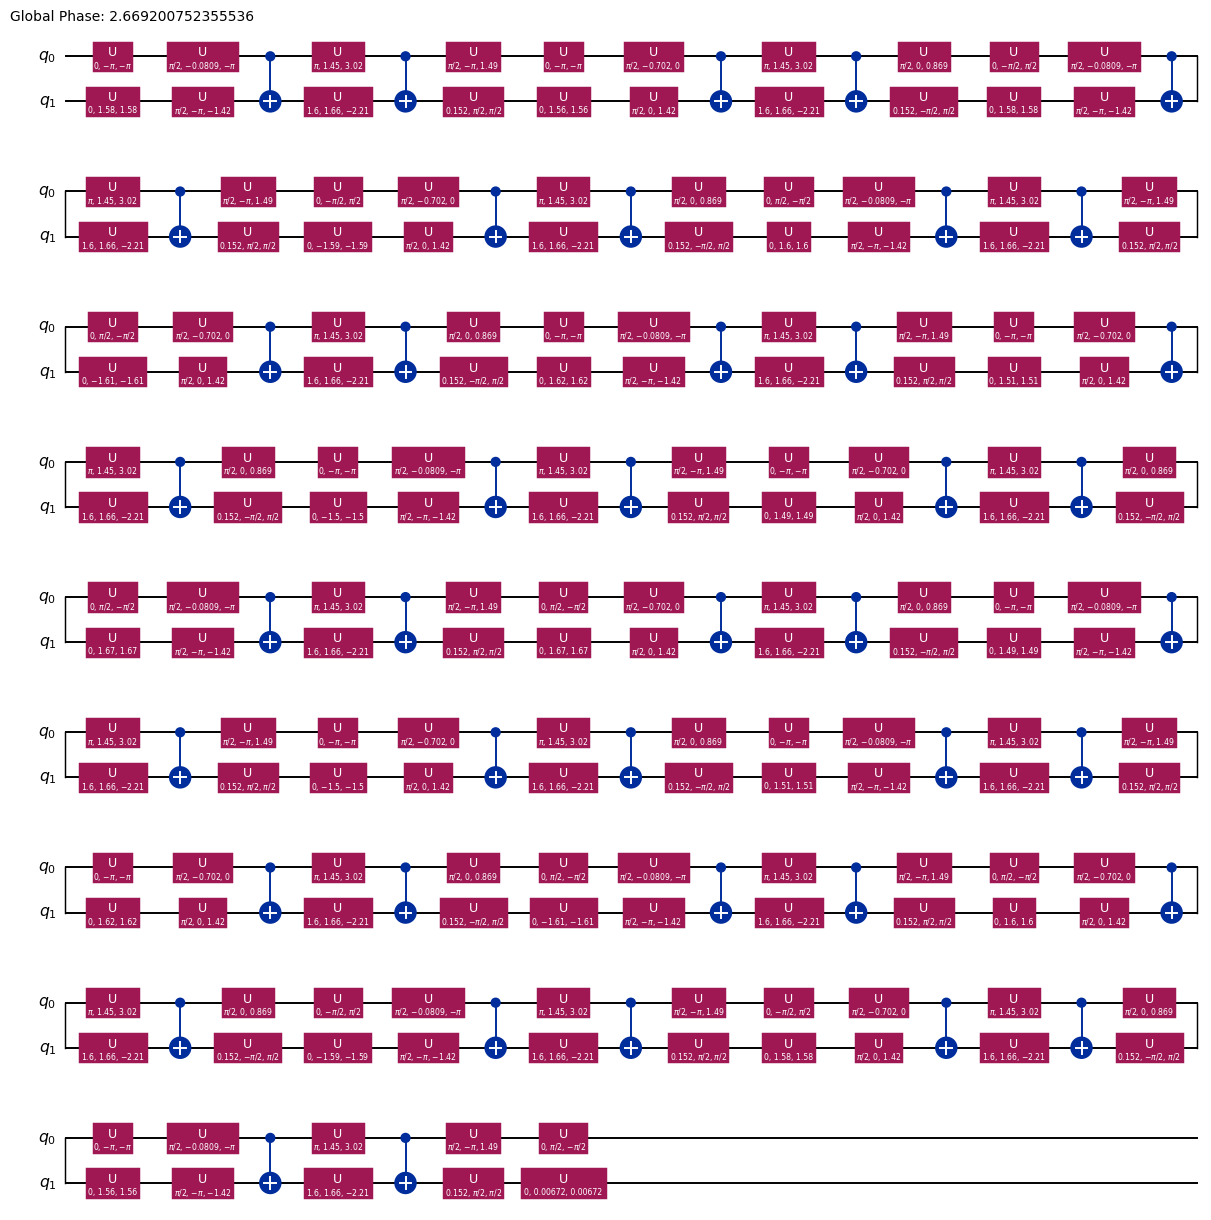

In [22]:
qsvt_circuit.decompose().draw('mpl', scale=0.7)

# pennylaneと比較


In [23]:
# PennyLaneでQSVTのユニタリ行列を確認
import pennylane as qml
import numpy as np

# テスト用の行列と角度
A = np.array([[3, 1], [1, 3]])
angles = angles_qsvt  # 前のセルで読み込んだ角度列

# QSVTのユニタリを計算
block_encoding = qml.BlockEncode(A, wires=[0, 1])
print("block_encoding", block_encoding)
projectors = [qml.PCPhase(angle, dim=2, wires=[0, 1]) for angle in angles]
print("projectors", projectors)

# matrixメソッドでユニタリを取得
qsvt_unitary = qml.matrix(qml.QSVT, wire_order=[0, 1])(block_encoding, projectors)

print(f"QSVT Unitary: \n {np.round(qsvt_unitary, 4)}")
print("\nOriginal matrix A:\n", A)

block_encoding BlockEncode(array([[0.1875, 0.0625],
       [0.0625, 0.1875]]), wires=[0, 1])
projectors [PCPhase(-4.719105187997574, wires=[0, 1]), PCPhase(1.579394407604872, wires=[0, 1]), PCPhase(1.5572499942939617, wires=[0, 1]), PCPhase(1.5906854463105513, wires=[0, 1]), PCPhase(1.5431138984871866, wires=[0, 1]), PCPhase(1.6076953640688814, wires=[0, 1]), PCPhase(1.5233905787146111, wires=[0, 1]), PCPhase(1.6297356890726742, wires=[0, 1]), PCPhase(1.4997124545196017, wires=[0, 1]), PCPhase(1.6540532381817377, wires=[0, 1]), PCPhase(1.476077815018265, wires=[0, 1]), PCPhase(1.476077815018265, wires=[0, 1]), PCPhase(1.6540532381817377, wires=[0, 1]), PCPhase(1.4997124545196017, wires=[0, 1]), PCPhase(1.6297356890726742, wires=[0, 1]), PCPhase(1.5233905787146111, wires=[0, 1]), PCPhase(1.6076953640688814, wires=[0, 1]), PCPhase(1.5431138984871866, wires=[0, 1]), PCPhase(1.5906854463105513, wires=[0, 1]), PCPhase(1.5572499942939617, wires=[0, 1]), PCPhase(1.579394407604872, wires=[0, 1

In [24]:
dev = qml.device("lightning.qubit", wires=[0, 1])
@qml.qnode(dev)
def my_circuit():
    qml.QSVT(block_encoding, projectors)
    return qml.state()

my_circuit()
print(qml.draw(my_circuit, level='device')())

0: ─╭∏_ϕ(-4.72)─╭BlockEncode(M0)─╭∏_ϕ(1.58)─╭BlockEncode(M0)─╭∏_ϕ(1.56)─╭BlockEncode(M0) ···
1: ─╰∏_ϕ(-4.72)─╰BlockEncode(M0)─╰∏_ϕ(1.58)─╰BlockEncode(M0)─╰∏_ϕ(1.56)─╰BlockEncode(M0) ···

0: ··· ─╭∏_ϕ(1.59)─╭BlockEncode(M0)─╭∏_ϕ(1.54)─╭BlockEncode(M0)─╭∏_ϕ(1.61)─╭BlockEncode(M0) ···
1: ··· ─╰∏_ϕ(1.59)─╰BlockEncode(M0)─╰∏_ϕ(1.54)─╰BlockEncode(M0)─╰∏_ϕ(1.61)─╰BlockEncode(M0) ···

0: ··· ─╭∏_ϕ(1.52)─╭BlockEncode(M0)─╭∏_ϕ(1.63)─╭BlockEncode(M0)─╭∏_ϕ(1.50)─╭BlockEncode(M0) ···
1: ··· ─╰∏_ϕ(1.52)─╰BlockEncode(M0)─╰∏_ϕ(1.63)─╰BlockEncode(M0)─╰∏_ϕ(1.50)─╰BlockEncode(M0) ···

0: ··· ─╭∏_ϕ(1.65)─╭BlockEncode(M0)─╭∏_ϕ(1.48)─╭BlockEncode(M0)─╭∏_ϕ(1.48)─╭BlockEncode(M0) ···
1: ··· ─╰∏_ϕ(1.65)─╰BlockEncode(M0)─╰∏_ϕ(1.48)─╰BlockEncode(M0)─╰∏_ϕ(1.48)─╰BlockEncode(M0) ···

0: ··· ─╭∏_ϕ(1.65)─╭BlockEncode(M0)─╭∏_ϕ(1.50)─╭BlockEncode(M0)─╭∏_ϕ(1.63)─╭BlockEncode(M0) ···
1: ··· ─╰∏_ϕ(1.65)─╰BlockEncode(M0)─╰∏_ϕ(1.50)─╰BlockEncode(M0)─╰∏_ϕ(1.63)─╰BlockEncode(M0) ···

0: ··· ─╭∏_ϕ(1.52)─╭BlockEncode(M0)─╭∏_ϕ(

In [18]:
phi = np.pi

# RZゲートの行列を生成（wireを指定する必要あり）
rz_matrix = qml.matrix(qml.RZ)(phi, wires=0)

print(np.round(rz_matrix, 4))

[[0.-1.j 0.+0.j]
 [0.+0.j 0.+1.j]]


In [14]:
# ============================================================================
# Π_φ(-4.72) の行列を確認 - Part 1: Qiskitの行列
# ============================================================================
print("=" * 80)
print("Π_φ(-4.72) の行列構造の確認")
print("=" * 80)

import numpy as np

# phase_matricesから最初の要素を取得
if len(phase_matrices) > 0:
    first_angle, first_matrix = phase_matrices[0]

    print(f"\n[Qiskit] 最初のPCPhaseゲート")
    print(f"  角度: {first_angle:.6f} rad = {np.degrees(first_angle):.2f}°")
    print(f"  行列のshape: {first_matrix.shape}")
    print(f"\n行列（実部）:")
    print(np.round(first_matrix.real, 6))
    print(f"\n行列（虚部）:")
    print(np.round(first_matrix.imag, 6))

    # 対角要素を確認
    print(f"\n\n対角要素の詳細:")
    for i in range(min(4, first_matrix.shape[0])):
        diag_elem = first_matrix[i, i]
        magnitude = np.abs(diag_elem)
        phase = np.angle(diag_elem)
        print(f"  U[{i},{i}] = {diag_elem.real:.6f} + {diag_elem.imag:.6f}i")
        print(f"           |U[{i},{i}]| = {magnitude:.6f}, ∠ = {phase:.6f} rad")

    # PCPhaseの理論値と比較
    print(f"\n\n[理論値との比較]")
    print(f"  入力角度 φ = {first_angle:.6f} rad")
    print(f"  期待される構造:")
    print(f"    i=0,1 (dim=2の範囲内):  exp(i*φ)")
    print(f"    i=2,3 (dim=2の範囲外):  exp(-i*φ)")

    # 理論値を計算
    exp_pos = np.exp(1j * first_angle)
    exp_neg = np.exp(-1j * first_angle)

    print(f"\n  exp(i*{first_angle:.4f})  = {exp_pos.real:.6f} + {exp_pos.imag:.6f}i")
    print(f"  exp(-i*{first_angle:.4f}) = {exp_neg.real:.6f} + {exp_neg.imag:.6f}i")

    # 一致確認
    print(f"\n\n[一致度チェック]")
    diffs = []
    for i in range(4):
        expected = exp_pos if i < 2 else exp_neg
        diff = abs(first_matrix[i, i] - expected)
        diffs.append(diff)
        status = "✅" if diff < 1e-10 else "⚠️"
        print(f"  U[{i},{i}]: 差分 = {diff:.2e} {status}")

    if max(diffs) < 1e-10:
        print(f"\n  ✅ すべて理論値と完全一致！")
else:
    print("\n⚠️ phase_matricesが空です")


Π_φ(-4.72) の行列構造の確認

[Qiskit] 最初のPCPhaseゲート
  角度: -4.719105 rad = -270.38°
  行列のshape: (4, 4)

行列（実部）:
[[0.006716 0.       0.       0.      ]
 [0.       0.006716 0.       0.      ]
 [0.       0.       0.006716 0.      ]
 [0.       0.       0.       0.006716]]

行列（虚部）:
[[ 0.999977  0.        0.        0.      ]
 [ 0.        0.999977  0.        0.      ]
 [ 0.        0.       -0.999977  0.      ]
 [ 0.        0.        0.       -0.999977]]


対角要素の詳細:
  U[0,0] = 0.006716 + 0.999977i
           |U[0,0]| = 1.000000, ∠ = 1.564080 rad
  U[1,1] = 0.006716 + 0.999977i
           |U[1,1]| = 1.000000, ∠ = 1.564080 rad
  U[2,2] = 0.006716 + -0.999977i
           |U[2,2]| = 1.000000, ∠ = -1.564080 rad
  U[3,3] = 0.006716 + -0.999977i
           |U[3,3]| = 1.000000, ∠ = -1.564080 rad


[理論値との比較]
  入力角度 φ = -4.719105 rad
  期待される構造:
    i=0,1 (dim=2の範囲内):  exp(i*φ)
    i=2,3 (dim=2の範囲外):  exp(-i*φ)

  exp(i*-4.7191)  = 0.006716 + 0.999977i
  exp(-i*-4.7191) = 0.006716 + -0.999977i


[一致度チェック]
  U[0,0]

In [16]:
from qiskit.circuit import QuantumCircuit

def pc_phase(phi, dim, wires):
    """
    Projector-Controlled Phase gate.

    Applies phase phi to subspace spanned by first 'dim' computational basis states.

    Args:
        phi: Phase angle
        dim: Dimension of subspace
        wires: List of qubit indices

    Returns:
        QuantumCircuit with PCPhase operation
    """
    num_qubits = len(wires)
    size = 2**num_qubits

    # Create diagonal unitary with phases
    U = np.eye(size, dtype=complex)

    # Apply phase to first 'dim' basis states
    for i in range(dim):
        U[i, i] = np.exp(1j * phi)

    # Apply conjugate phase to remaining states
    for i in range(dim, size):
        U[i, i] = np.exp(-1j * phi)
    print(f"PCPhase(φ={phi:.4f}, dim={dim}) matrix:")
    print(np.round(U, 4))

    qc = QuantumCircuit(num_qubits)
    qc.unitary(U, wires, label="PCPhase")


    return qc


pc_phase = pc_phase(-4.719105187997574, 2, [0, 1])
print(pc_phase)
print(-4.719105187997574/np.pi)

PCPhase(φ=-4.7191, dim=2) matrix:
[[0.0067+1.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.0067+1.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.0067-1.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.0067-1.j]]
     ┌──────────┐
q_0: ┤0         ├
     │  PCPhase │
q_1: ┤1         ├
     └──────────┘
-1.5021378352808439
